#**Project Title:**
**Fake News Detection using Natural Language Processing and Machine Learning**

#**Problem Statement:**
**The rapid spread of fake news on social media and online platforms has made it difficult to identify trustworthy information. This project aims to build a Machine Learning model that automatically classifies news articles as Fake or Real using Natural Language Processing (NLP).**

#**Objective:**
- Load Fake and Real news datasets.
- Merge them into one dataset.
- Perform Exploratory Data Analysis (EDA).
- Check missing values and duplicates.
- Analyze class distribution.
- Prepare the dataset for NLP preprocessing.

**Import Libraries:**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset:**

In [ ]:
fake = pd.read_csv("/content/drive/MyDrive/Fake.csv")
true = pd.read_csv("/content/drive/MyDrive/True.csv")

**Display First 5 Rows**

In [ ]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


**Check Dataset Shape:**

In [ ]:
print("Fake Dataset Shape :", fake.shape)
print("True Dataset Shape :", true.shape)

Fake Dataset Shape : (23481, 4)
True Dataset Shape : (21417, 4)


**Observation**
- Fake dataset contains 23,481 news articles.
- True dataset contains 21,417 news articles.
- Both datasets have 4 columns.

**Add Target Labels:**

In [ ]:
fake["label"] = 0
true["label"] = 1

**Observation**
- 0 → Fake News
- 1 → Real News

The label column will act as the target variable during model training.

**Merge Both Datasets:**

In [ ]:
df = pd.concat([fake, true], ignore_index=True)

**Display Merged Dataset:**

In [ ]:
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [ ]:
print(df.shape)

(44898, 5)


**Observation**
- Total records = 44,898
- Total columns = 5
- The additional column is the target label.

**Dataset Information:**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


**Observation**
- Total rows: 44,898
- Total columns: 5
- title, text, subject, and date are object data types.
- label is an integer column used for prediction.

**Statistical Summary:**

In [ ]:
df.describe(include="all")

,title,text,subject,date,label
count,44898,44898,44898,44898,44898.000000
unique,38729,38646,8,2397,NaN
top,Factbox: Trump fills top jobs for his administ...,,politicsNews,"December 20, 2017",NaN
freq,14,627,11272,182,NaN
mean,NaN,NaN,NaN,NaN,0.477015
std,NaN,NaN,NaN,NaN,0.499477
min,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,1.000000


**Observation**
- Displays summary statistics for both numerical and categorical columns.
- Helps identify unique values and the most frequent category.

**Check Missing Values:**

In [ ]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


**Observation**
- No missing values are present.

**Check Duplicate Records:**

In [ ]:
df.duplicated().sum()

np.int64(209)

**Observation**

- Duplicate records may exist after merging the datasets and should be removed before model training.

**Remove Duplicate Records:**

In [ ]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

In [ ]:
df.shape

(44689, 5)

**Observation**

- when duplicate rows are removed, the total number of records decreases. This helps prevent the model from learning repeated information.

**Check Class Distribution:**

In [ ]:
df["label"].value_counts()

,count
label,
0,23478
1,21211


**Observation**
- Fake News = 23,478
- Real News = 21,211
- The dataset is relatively balanced.

**Visualize Class Distribution:**

/tmp/ipykernel_1229/145272582.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


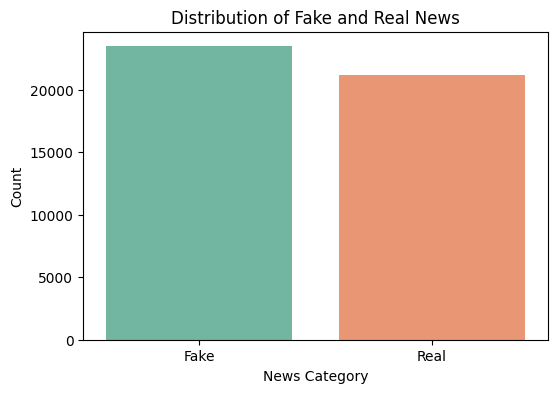

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="label",
    palette="Set2"
)

plt.xticks([0,1],["Fake","Real"])

plt.title("Distribution of Fake and Real News")
plt.xlabel("News Category")
plt.ylabel("Count")

plt.show()

**Observation**
- Both classes contain a similar number of records.
- No severe class imbalance is observed.

**Check Subject Distribution:**

In [ ]:
df["subject"].value_counts()

,count
subject,
politicsNews,11220
worldnews,9991
News,9050
politics,6838
left-news,4459
Government News,1570
US_News,783
Middle-east,778


**Observation**

- This shows how many articles belong to each subject (such as politics, world news, government news, etc.), helping us understand the dataset composition.

**Check Unique Subjects:**

In [ ]:
print(df["subject"].unique())

['News' 'politics' 'Government News' 'left-news' 'US_News' 'Middle-east'
 'politicsNews' 'worldnews']


**Observation**

- The dataset contains multiple news categories. Subject information can later be explored as an additional feature, although the primary focus of this project will be the textual content.

**Inspect Date Column:**

In [ ]:
df["date"].head()

,date
0,"December 31, 2017"
1,"December 31, 2017"
2,"December 30, 2017"
3,"December 29, 2017"
4,"December 25, 2017"


**Observation**

- The date column is stored as text. It can be converted to datetime for time-based analysis if required, but it is not essential for the baseline NLP model.

# **Text Preprocessing:**

In [ ]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

**Combine Title and Text:**

In [ ]:
df["content"] = df["title"] + " " + df["text"]

In [ ]:
df[["title","text","content"]].head()

,title,text,content
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,Donald Trump Sends Out Embarrassing New Year’...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,Drunk Bragging Trump Staffer Started Russian ...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",Sheriff David Clarke Becomes An Internet Joke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",Trump Is So Obsessed He Even Has Obama’s Name...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,Pope Francis Just Called Out Donald Trump Dur...


**Observation**

- The new content column contains both the headline and article body, giving the model more information for prediction.

**Convert to Lowercase:**

In [ ]:
df["content"] = df["content"].str.lower()

In [ ]:
df["content"].head()

,content
0,donald trump sends out embarrassing new year’...
1,drunk bragging trump staffer started russian ...
2,sheriff david clarke becomes an internet joke...
3,trump is so obsessed he even has obama’s name...
4,pope francis just called out donald trump dur...


**Observation**

- Lowercase conversion ensures that words such as "Trump" and "trump" are treated as the same token.

**Remove URLs:**

In [ ]:
def remove_url(text):
    return re.sub(r"http\S+|www\S+","",text)

df["content"] = df["content"].apply(remove_url)

**Observation**

- URLs do not contribute to identifying fake or real news and are therefore removed.

**Remove HTML Tags:**

In [ ]:
def remove_html(text):
    return re.sub(r"<.*?>","",text)

df["content"] = df["content"].apply(remove_html)

**Observation**

- HTML tags are removed because they do not contain useful textual information.

**Remove Punctuation:**

In [ ]:
def remove_punctuation(text):
    return text.translate(
        str.maketrans("","",string.punctuation)
    )

df["content"] = df["content"].apply(remove_punctuation)

**Observation**

- Punctuation marks are removed to reduce noise in the text.

**Remove Numbers:**

In [ ]:
def remove_numbers(text):
    return re.sub(r"\d+","",text)

df["content"] = df["content"].apply(remove_numbers)

**Observation**

- Numbers usually have limited importance for fake news classification.

**Remove Extra Spaces:**

In [ ]:
def remove_spaces(text):
    return re.sub(r"\s+"," ",text).strip()

df["content"] = df["content"].apply(remove_spaces)

**Observation**

- Extra spaces are removed to standardize the text.

**Tokenization:**

In [ ]:
df["tokens"] = df["content"].apply(word_tokenize)

In [ ]:
df["tokens"].head()

,tokens
0,"[donald, trump, sends, out, embarrassing, new,..."
1,"[drunk, bragging, trump, staffer, started, rus..."
2,"[sheriff, david, clarke, becomes, an, internet..."
3,"[trump, is, so, obsessed, he, even, has, obama..."
4,"[pope, francis, just, called, out, donald, tru..."


**Observation**

- Tokenization splits the sentence into individual words.

**Remove Stopwords:**

In [ ]:
stop_words = set(stopwords.words("english"))

df["tokens"] = df["tokens"].apply(
    lambda words: [
        word for word in words
        if word not in stop_words
    ]
)

**Observation**

- Common words such as is, the, and, of are removed because they carry very little meaning.

**Lemmatization:**

In [ ]:
lemmatizer = WordNetLemmatizer()

df["tokens"] = df["tokens"].apply(
    lambda words: [
        lemmatizer.lemmatize(word)
        for word in words
    ]
)

**Observation**

- Lemmatization converts words to their root form.

**Create Clean Text:**

In [ ]:
df["clean_text"] = df["tokens"].apply(
    lambda words: " ".join(words)
)

In [ ]:
df[["content","clean_text"]].head()

,content,clean_text
0,donald trump sends out embarrassing new year’s...,donald trump sends embarrassing new year ’ eve...
1,drunk bragging trump staffer started russian c...,drunk bragging trump staffer started russian c...
2,sheriff david clarke becomes an internet joke ...,sheriff david clarke becomes internet joke thr...
3,trump is so obsessed he even has obama’s name ...,trump obsessed even obama ’ name coded website...
4,pope francis just called out donald trump duri...,pope francis called donald trump christmas spe...


**Observation**

- The cleaned text is now ready for TF-IDF vectorization and model training.

**Character Count:**

In [ ]:
df["char_count"] = df["clean_text"].apply(len)

**Word Count:**

In [ ]:
df["word_count"] = df["clean_text"].apply(
    lambda x: len(x.split())
)

**Average Word Length:**

In [ ]:
df["avg_word_length"] = df["clean_text"].apply(
    lambda x: (
        sum(len(word) for word in x.split()) /
        len(x.split())
    )
    if len(x.split()) > 0 else 0
)

In [ ]:
df.head()

,title,text,subject,date,label,content,tokens,clean_text,char_count,word_count,avg_word_length
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,donald trump sends out embarrassing new year’s...,"[donald, trump, sends, embarrassing, new, year...",donald trump sends embarrassing new year ’ eve...,1858,268,5.936567
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,drunk bragging trump staffer started russian c...,"[drunk, bragging, trump, staffer, started, rus...",drunk bragging trump staffer started russian c...,1436,186,6.725806
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,sheriff david clarke becomes an internet joke ...,"[sheriff, david, clarke, becomes, internet, jo...",sheriff david clarke becomes internet joke thr...,2418,327,6.397554
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0,trump is so obsessed he even has obama’s name ...,"[trump, obsessed, even, obama, ’, name, coded,...",trump obsessed even obama ’ name coded website...,1833,252,6.277778
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0,pope francis just called out donald trump duri...,"[pope, francis, called, donald, trump, christm...",pope francis called donald trump christmas spe...,1476,218,5.775229


In [ ]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0
content,0
tokens,0
clean_text,0
char_count,0
word_count,0


**Observation**

- No missing values should be present after preprocessing.

#**Exploratory Data Analysis (EDA):**

In [ ]:
from wordcloud import WordCloud
from collections import Counter

**Character Count Distribution:**

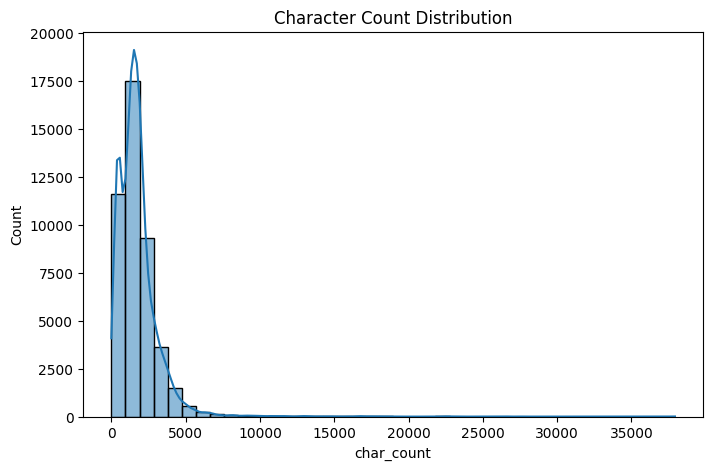

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="char_count",
    bins=40,
    kde=True
)

plt.title("Character Count Distribution")

plt.show()

**Observation**
- Most news articles contain a moderate number of characters.
- Very short and very long articles are comparatively fewer.

**Word Count Distribution:**

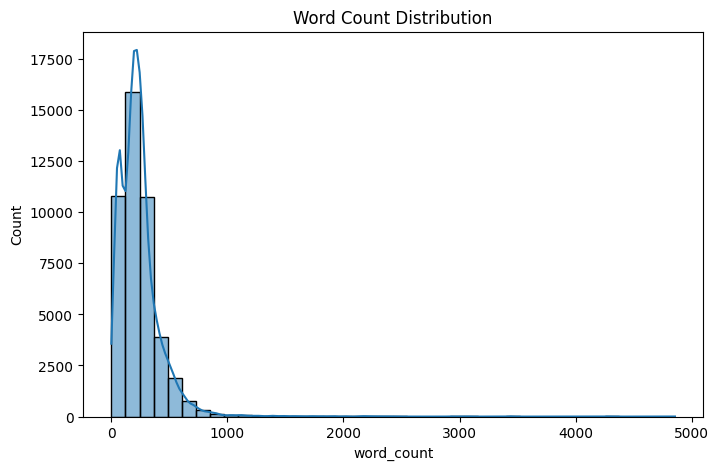

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="word_count",
    bins=40,
    kde=True
)

plt.title("Word Count Distribution")

plt.show()

**Observation**
- Most articles contain a moderate number of words.
- Few articles have exceptionally high word counts.

**Average Word Length:**

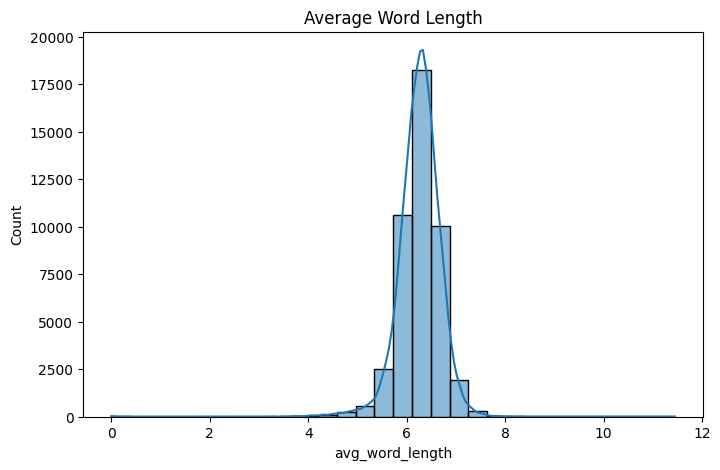

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="avg_word_length",
    bins=30,
    kde=True
)

plt.title("Average Word Length")

plt.show()

**Observation**

- The average word length is relatively consistent across the dataset, indicating standardized English vocabulary.

**Boxplot:**

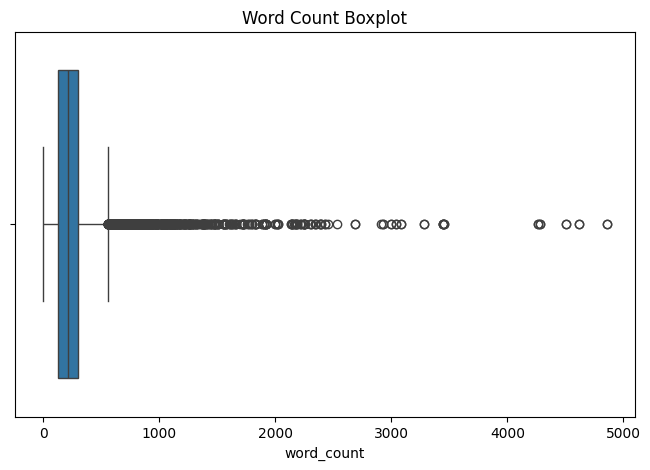

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["word_count"]
)

plt.title("Word Count Boxplot")

plt.show()

**Observation**

- A few news articles have unusually high word counts, which appear as outliers.

**WordCloud (All News):**

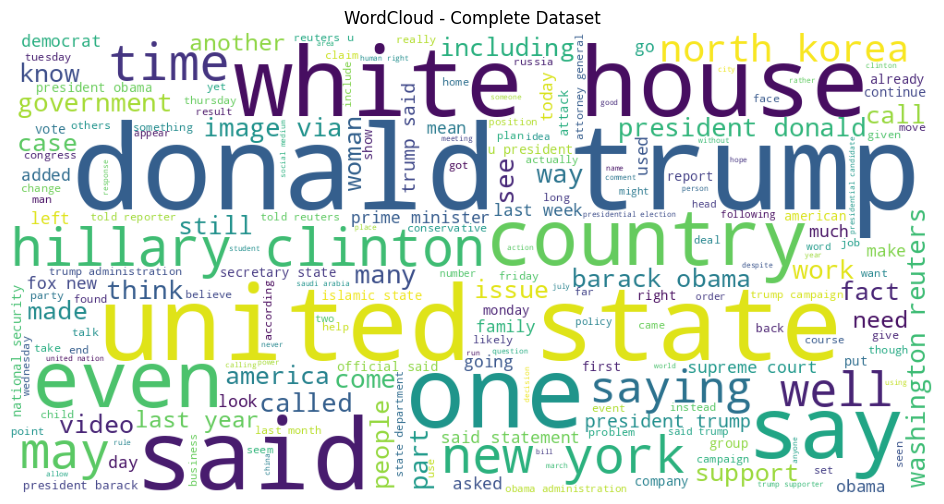

In [ ]:
text = " ".join(df["clean_text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("WordCloud - Complete Dataset")

plt.show()

**Observation**

- Frequently occurring words appear larger, providing an overview of the most common vocabulary used in the dataset.

**Fake vs Real News Distribution:**

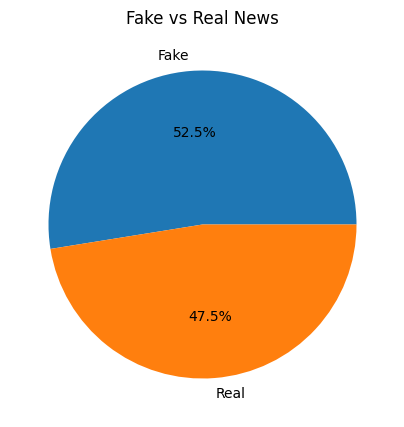

In [ ]:
plt.figure(figsize=(5,5))

df["label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Fake","Real"]
)

plt.ylabel("")

plt.title("Fake vs Real News")

plt.show()

**Observation**

- The dataset is nearly balanced, reducing the need for resampling techniques.

#**Feature Extraction (TF-IDF):**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

**Input and Target:**

In [ ]:
X = df["clean_text"]

y = df["label"]

**Observation**
- X → Cleaned News Articles
- y → Target Labels (0 = Fake, 1 = Real)

**Train-Test Split:**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

 **Check Shape:**

In [ ]:
print("X_train :", X_train.shape)

print("X_test :", X_test.shape)

print("y_train :", y_train.shape)

print("y_test :", y_test.shape)

X_train : (35751,)
X_test : (8938,)
y_train : (35751,)
y_test : (8938,)


**Observation**
- 80% data is used for training.
- 20% data is reserved for testing.
- stratify=y maintains the same Fake/Real ratio in both sets.

**TF-IDF Vectorizer:**

In [ ]:
tfidf = TfidfVectorizer(

    max_features=20000,

    stop_words="english",

    ngram_range=(1,2),

    min_df=2,

    max_df=0.95

)

**Observation**

- These settings reduce noise, improve generalization, and usually perform well on large news datasets.

**Fit on Training Data:**

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

**Check Matrix Shape:**

In [ ]:
print("Train Matrix :", X_train_tfidf.shape)

print("Test Matrix :", X_test_tfidf.shape)

Train Matrix : (35751, 20000)
Test Matrix : (8938, 20000)


**Observation:**
- Each news article is converted into a 20,000-dimensional numerical vector.

**Check Sparse Matrix:**

In [ ]:
print(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5687475 stored elements and shape (35751, 20000)>
  Coords	Values
  (0, 18135)	0.046129456418168124
  (0, 6921)	0.03510365315522568
  (0, 17924)	0.07571718841373604
  (0, 13693)	0.07352951499886734
  (0, 9482)	0.326926580189109
  (0, 5879)	0.13957230449776767
  (0, 8976)	0.12212612705449531
  (0, 9798)	0.04264325593351459
  (0, 2084)	0.02879820045553638
  (0, 15337)	0.11106214658417606
  (0, 7756)	0.10191602666252064
  (0, 15308)	0.11357462348072896
  (0, 4119)	0.02053998007239023
  (0, 12217)	0.060483778894144836
  (0, 4849)	0.02062632724081282
  (0, 13688)	0.05641647040188523
  (0, 17210)	0.03148154778286478
  (0, 523)	0.07808561582905302
  (0, 15786)	0.020359700898404862
  (0, 17738)	0.03319321418483538
  (0, 2581)	0.09218133971861343
  (0, 5882)	0.023937055354919776
  (0, 2668)	0.026843577615077507
  (0, 3022)	0.01414168977227241
  (0, 6480)	0.5251252946565901
  :	:
  (35750, 11682)	0.07676199224086906
  (35750, 3842)	0.

**Observation**

- TF-IDF creates a Sparse Matrix, where most values are zero because each news article contains only a small fraction of the overall vocabulary.

**Convert First Row to Dense (Demo):**

In [ ]:
X_train_tfidf[0].toarray()

array([[0., 0., 0., ..., 0., 0., 0.]])

**Observation**

- This converts one sparse vector into a dense array for inspection. Normally, sparse format is preferred because it is memory efficient.

**Save TF-IDF Vectorizer:**

In [ ]:
import joblib

joblib.dump(

    tfidf,

    "tfidf_vectorizer.pkl"

)

['tfidf_vectorizer.pkl']

**Observation**

- Saving the vectorizer ensures that future news articles are transformed using the same vocabulary during deployment.

**Model Building:**

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

**Train Multinomial Naive Bayes:**

In [ ]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

MultinomialNB()

**Prediction:**

In [ ]:
nb_pred = nb_model.predict(
    X_test_tfidf
)

**Train Logistic Regression:**

In [ ]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

**Prediction:**

In [ ]:
lr_pred = lr_model.predict(
    X_test_tfidf
)

**Train Linear SVM:**

In [ ]:
svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

LinearSVC(random_state=42)

**Prediction:**

In [ ]:
svm_pred = svm_model.predict(
    X_test_tfidf
)

**Train Decision Tree:**

In [ ]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train_tfidf,
    y_train
)

DecisionTreeClassifier(random_state=42)

**Prediction:**

In [ ]:
dt_pred = dt_model.predict(
    X_test_tfidf
)

**Create Evaluation Function:**

In [ ]:
def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(y_true, y_pred)

    recall = recall_score(y_true, y_pred)

    f1 = f1_score(y_true, y_pred)

    return [
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ]

**Evaluate All Models:**

In [ ]:
results = []

results.append(
    evaluate_model(
        "Naive Bayes",
        y_test,
        nb_pred
    )
)

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_pred
    )
)

results.append(
    evaluate_model(
        "Linear SVM",
        y_test,
        svm_pred
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        dt_pred
    )
)

**Comparison Table:**

In [ ]:
comparison = pd.DataFrame(

    results,

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ]

)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.948199,0.944693,0.946252,0.945472
1,Logistic Regression,0.989147,0.986617,0.990570,0.988590
2,Linear SVM,0.995413,0.994584,0.995757,0.995170
3,Decision Tree,0.995860,0.996927,0.994342,0.995633


**Sort Results:**

In [ ]:
comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
3,Decision Tree,0.995860,0.996927,0.994342,0.995633
2,Linear SVM,0.995413,0.994584,0.995757,0.995170
1,Logistic Regression,0.989147,0.986617,0.990570,0.988590
0,Naive Bayes,0.948199,0.944693,0.946252,0.945472


**Best Model:**

In [ ]:
best_model = comparison.iloc[0]

print(best_model)

Model        Decision Tree
Accuracy           0.99586
Precision         0.996927
Recall            0.994342
F1 Score          0.995633
Name: 3, dtype: object


**Save Best Model:**

In [ ]:
import joblib

joblib.dump(
    dt_model,
    "fake_news_model.pkl"
)

['fake_news_model.pkl']

**Observations**
- Trained four Machine Learning models on TF-IDF features.
- Generated predictions on the unseen test dataset.
- Compared all models using Accuracy, Precision, Recall, and F1-Score.
- Identified the best-performing model.
- Saved the final model for deployment.